In [15]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Load the clean data
df = pd.read_csv("preprocessed_oulad_data.csv")

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Ready for modeling!")

Ready for modeling!


In [17]:
# 1. Define your features (X) and target (y)
# We drop 'id_student' because it's just an ID, and 'final_result' to avoid data leakage
cols_to_drop = ['id_student', 'target', 'final_result'] 
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df['target']

# 2. Convert categorical columns (like gender, region, etc.) into numbers using One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# 3. Handle missing values (Scikit-Learn's Random Forest cannot handle NaN values natively)
# We will fill missing numeric values with the median of their respective columns
X = X.fillna(X.median())

print(f"Features ready! Total number of features: {X.shape[1]}")

Features ready! Total number of features: 43


In [18]:
# Split 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (26074, 43)
Testing data shape: (6519, 43)


In [19]:
# Initialize the model
# We use class_weight='balanced' to help the model pay equal attention to both passing and failing students
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
rf_model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [20]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Print the results
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.6998005829114895

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.72      0.71      0.71      3442
           1       0.68      0.69      0.68      3077

    accuracy                           0.70      6519
   macro avg       0.70      0.70      0.70      6519
weighted avg       0.70      0.70      0.70      6519



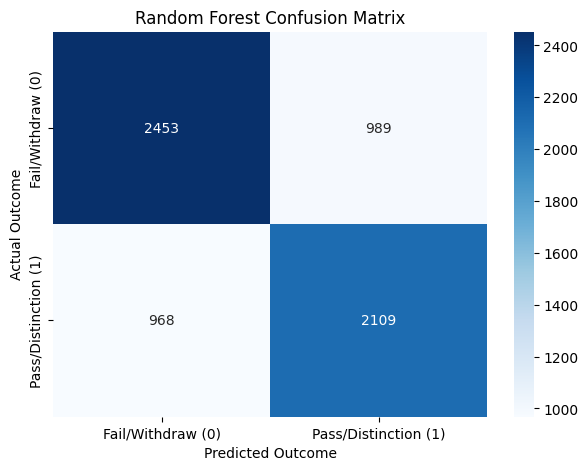

In [21]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it using Seaborn
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fail/Withdraw (0)', 'Pass/Distinction (1)'], 
            yticklabels=['Fail/Withdraw (0)', 'Pass/Distinction (1)'])
plt.ylabel('Actual Outcome')
plt.xlabel('Predicted Outcome')
plt.title('Random Forest Confusion Matrix')
plt.show()

C:\Users\shaik\AppData\Local\Temp\ipykernel_22288\2641280898.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


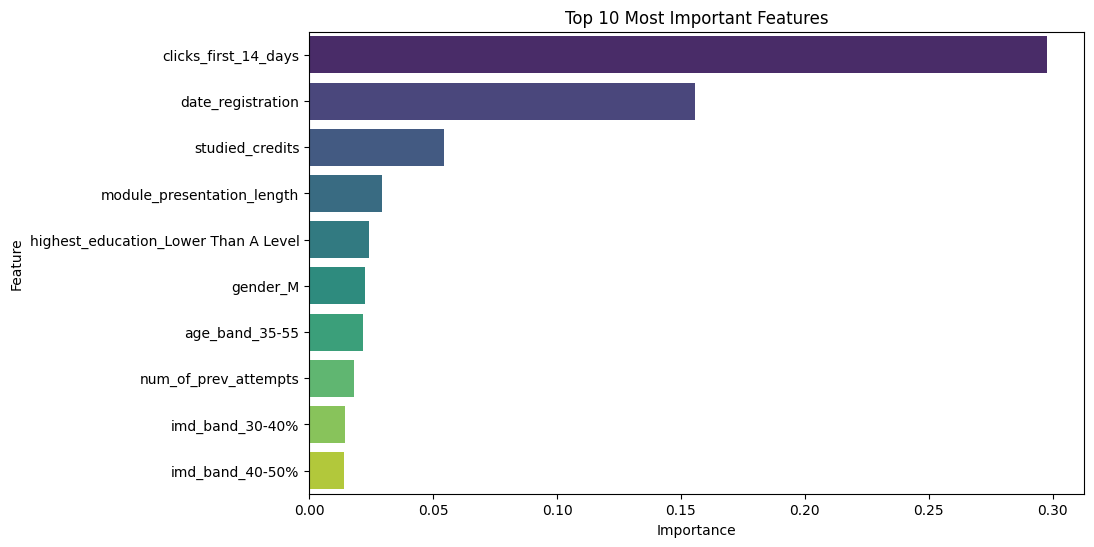

In [22]:
# Get feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame and sort it
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features')
plt.show()

In [23]:
import re

# 1. Define features (X) and target (y)
cols_to_drop = ['id_student', 'target', 'final_result'] 
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df['target']

# 2. One-Hot Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# 3. BULLETPROOF CLEANING: Replace ALL characters that XGBoost hates using Regex
# This replaces [, ], <, >, =, spaces, and commas with an underscore (_)
X.columns = [re.sub(r'[\[\]<>=, \s]', '_', str(col)) for col in X.columns]

# 4. Handle missing values
X = X.fillna(X.median())

# 5. Split the data IMMEDIATELY so the clean names carry over to X_train/X_test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Data cleaned and split successfully!")
print(f"X_train shape: {X_train.shape}")

Data cleaned and split successfully!
X_train shape: (26074, 43)


In [24]:
from xgboost import XGBClassifier

# Initialize XGBoost
# Use scale_pos_weight to handle the slight imbalance (similar to class_weight='balanced')
xgb_model = XGBClassifier(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=42,
    eval_metric='logloss'
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict and Evaluate
xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("\n--- XGBoost Classification Report ---")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.7145267679091886

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.69      0.72      3442
           1       0.68      0.74      0.71      3077

    accuracy                           0.71      6519
   macro avg       0.72      0.72      0.71      6519
weighted avg       0.72      0.71      0.71      6519

